In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from xgboost import XGBRegressor

In [ ]:
df = pd.read_csv("sales_data.csv") #importing data to start the analysis process 
df.head() # display the first 5 rows of the dataset

,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Region_and_Sales_Rep
0,1052,03/02/2023,Bob,North,"5,053.97",18,Furniture,152.75,267.22,Returning,0.09,Cash,Online,North-Bob
1,1093,21/04/2023,Bob,West,"4,384.02",17,Furniture,"3,816.39","4,209.44",Returning,0.11,Cash,Retail,West-Bob
2,1015,21/09/2023,David,South,"4,631.23",30,Food,261.56,371.40,Returning,0.20,Bank Transfer,Retail,South-David
3,1072,24/08/2023,Bob,South,"2,167.94",39,Clothing,"4,330.03","4,467.75",New,0.02,Credit Card,Retail,South-Bob
4,1061,24/03/2023,Charlie,East,"3,750.20",13,Electronics,637.37,692.71,New,0.08,Credit Card,Online,East-Charlie


In [ ]:
#Data Cleaning Processes 

In [ ]:
df = df.drop('Region_and_Sales_Rep', axis=1) #remove unnecessary columns

In [ ]:
df.columns # check to ensure the previous step has done 

Index(['Product_ID', 'Sale_Date', 'Sales_Rep', 'Region', 'Sales_Amount',
       'Quantity_Sold', 'Product_Category', 'Unit_Cost', 'Unit_Price',
       'Customer_Type', 'Discount', 'Payment_Method', 'Sales_Channel'],
      dtype='object')

In [ ]:
df.isnull().sum()  # check to detict if there is any null values 

Product_ID          0
Sale_Date           0
Sales_Rep           0
Region              0
Sales_Amount        0
Quantity_Sold       0
Product_Category    0
Unit_Cost           0
Unit_Price          0
Customer_Type       0
Discount            0
Payment_Method      0
Sales_Channel       0
dtype: int64

In [ ]:
df.duplicated().sum() # check there is any duplicated values 

np.int64(0)

In [ ]:
df.dtypes  #check the data type of each column is correct

Product_ID            int64
Sale_Date            object
Sales_Rep            object
Region               object
Sales_Amount        float64
Quantity_Sold         int64
Product_Category     object
Unit_Cost           float64
Unit_Price          float64
Customer_Type        object
Discount            float64
Payment_Method       object
Sales_Channel        object
dtype: object

In [ ]:
df['Sale_Date'] = pd.to_datetime(df['Sale_Date'], dayfirst=True)  # Date column data type correction 

In [ ]:
df['Sale_Date'].dtype # Ensure the previous step done correctly and the date column data type shows 'dtype'

dtype('<M8[ns]')

In [ ]:
df[(df['Quantity_Sold'] < 0) | (df['Unit_Price'] < 0)] #detect invalid values

,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel


In [ ]:
df['Calculated_Sales'] = df['Quantity_Sold'] * df['Unit_Price'] * (1 - df['Discount']) # check the accuracy of sales calculation 

In [ ]:
df[['Sales_Amount', 'Calculated_Sales']].head() #Detict the differences 

,Sales_Amount,Calculated_Sales
0,"5,053.97","4,377.06"
1,"4,384.02","63,688.83"
2,"4,631.23","8,913.60"
3,"2,167.94","170,757.40"
4,"3,750.20","8,284.81"


In [ ]:
df['Sales_Amount_Correct'] = df['Quantity_Sold'] * df['Unit_Price'] * (1 - df['Discount']) # add a new column that Recalculating the sales amount 

In [ ]:
df['Sales_Amount'] = df['Sales_Amount_Correct'] #create a new column Sales_Amount by copying values from Sales_Amount_Correct.

In [ ]:
cols_to_drop = ['Calculated_Sales', 'Sales_Amount_Correct', 'Difference']
df = df.drop(columns=[col for col in cols_to_drop if col in df.columns]) #remove the specified columns from the DataFrame if they exist, to avoid errors when dropping missing columns.

In [ ]:
# Exploratory Data Analysis Part 

In [ ]:
df['Profit'] = (df['Unit_Price'] - df['Unit_Cost']) * df['Quantity_Sold'] # add a new column displays the profitability amount 

In [ ]:
df[['Unit_Price', 'Unit_Cost', 'Quantity_Sold', 'Profit']].head() # show the first 5 rows of profit column 

,Unit_Price,Unit_Cost,Quantity_Sold,Profit
0,267.22,152.75,18,"2,060.46"
1,"4,209.44","3,816.39",17,"6,681.85"
2,371.40,261.56,30,"3,295.20"
3,"4,467.75","4,330.03",39,"5,371.08"
4,692.71,637.37,13,719.42


In [ ]:
df['Profit'].sum() #calculate the total profit by summing all values in the Profit column.

np.float64(6487847.07)

In [ ]:
df['Profit'].mean() #calculate the average profit from all sales records.

np.float64(6487.847070000001)

<Axes: xlabel='Sales_Amount'>

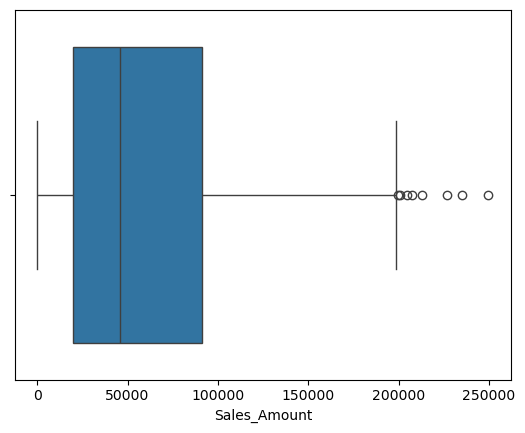

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df['Sales_Amount']) #visualize the distribution of Sales_Amount and helps detect outliers.

In [ ]:
q1 = df['Sales_Amount'].quantile(0.25)
q3 = df['Sales_Amount'].quantile(0.75)
iqr = q3 - q1

outliers = df[(df['Sales_Amount'] < q1 - 1.5*iqr) | (df['Sales_Amount'] > q3 + 1.5*iqr)]

outliers.shape #identifies and returns the number of outliers in Sales_Amount using the IQR method.

(8, 14)

In [ ]:
#(8,14) The result means the data contains 14 columns and 8 outliers values 

In [ ]:
df.sort_values('Sales_Amount', ascending=False).head(10) #show the top 10 highest sales records based on Sales_Amount.

,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Profit
962,1090,2023-10-15,Charlie,South,"249,625.89",48,Electronics,"4,766.53","5,253.07",Returning,0.01,Bank Transfer,Online,"23,353.92"
806,1001,2023-05-10,David,East,"234,866.62",47,Food,"4,865.33","5,316.13",New,0.06,Bank Transfer,Online,"21,187.60"
170,1032,2023-06-08,Eve,West,"226,873.92",49,Electronics,"4,812.41","5,088.00",Returning,0.09,Credit Card,Online,"13,503.91"
672,1037,2023-01-09,Charlie,North,"212,818.65",41,Clothing,"4,965.07","5,243.13",New,0.01,Credit Card,Online,"11,400.46"
844,1050,2023-07-18,Eve,South,"207,439.68",43,Furniture,"4,834.47","4,973.38",Returning,0.03,Bank Transfer,Online,"5,973.13"
984,1057,2023-06-08,Charlie,East,"204,698.44",43,Furniture,"4,567.39","4,958.78",New,0.04,Cash,Retail,"16,829.77"
633,1099,2023-08-29,Alice,West,"200,811.52",44,Clothing,"4,933.11","5,245.86",Returning,0.13,Bank Transfer,Retail,"13,761.00"
264,1067,2023-06-29,Eve,South,"199,824.19",48,Food,"4,319.32","4,625.56",Returning,0.10,Bank Transfer,Online,"14,699.52"
850,1094,2023-01-15,Bob,North,"198,621.34",45,Furniture,"4,470.91","4,695.54",Returning,0.06,Cash,Retail,"10,108.35"
203,1097,2023-10-30,Eve,West,"196,658.25",49,Electronics,"4,264.46","4,315.52",New,0.07,Cash,Retail,"2,501.94"


In [ ]:
df['Profit_Margin'] = df['Profit'] / df['Sales_Amount'] # add a new column to Calculate The Profit Margin 

In [ ]:
import pandas as pd

pd.options.display.float_format = '{:,.2f}'.format #format floating-point numbers

In [ ]:
category_sales = df.groupby('Product_Category')['Sales_Amount'].sum().sort_values(ascending=False)
category_sales

Product_Category
Clothing      16,360,844.62
Furniture     15,363,777.14
Electronics   15,153,225.29
Food          12,808,326.23
Name: Sales_Amount, dtype: float64

In [ ]:
df.groupby('Product_Category')['Profit'].sum().sort_values(ascending=False) #shows total profit per product category and ranks them from highest to lowest.

Product_Category
Furniture     1,779,461.16
Clothing      1,712,957.80
Electronics   1,574,320.06
Food          1,421,108.05
Name: Profit, dtype: float64

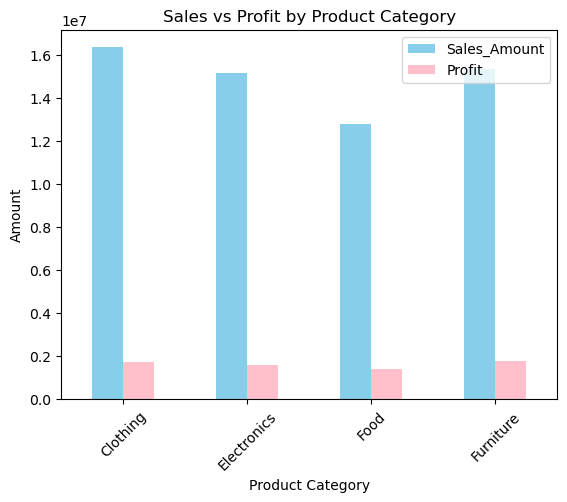

In [ ]:
import matplotlib.pyplot as plt
category_sales = df.groupby('Product_Category')['Sales_Amount'].sum()
profit_by_category = df.groupby('Product_Category')['Profit'].sum()
combined = df.groupby('Product_Category')[['Sales_Amount', 'Profit']].sum()
combined.plot(kind='bar', color=['skyblue', 'pink'])
plt.title('Sales vs Profit by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Amount')
plt.xticks(rotation=45)
plt.show()

In [ ]:
df['Month'] = df['Sale_Date'].dt.to_period('M')

monthly_sales_profit = df.groupby('Month')[['Sales_Amount', 'Profit']].sum()
monthly_sales_profit

,Sales_Amount,Profit
Month,,
2023-01,"6,375,602.77","655,202.59"
2023-02,"4,662,249.50","478,053.08"
2023-03,"5,111,669.96","528,631.81"
2023-04,"4,518,199.64","496,006.82"
2023-05,"4,878,261.79","489,472.15"
2023-06,"5,296,112.00","605,992.20"
2023-07,"4,003,580.31","447,678.76"
2023-08,"5,724,989.74","558,417.69"
2023-09,"3,835,193.09","472,940.52"


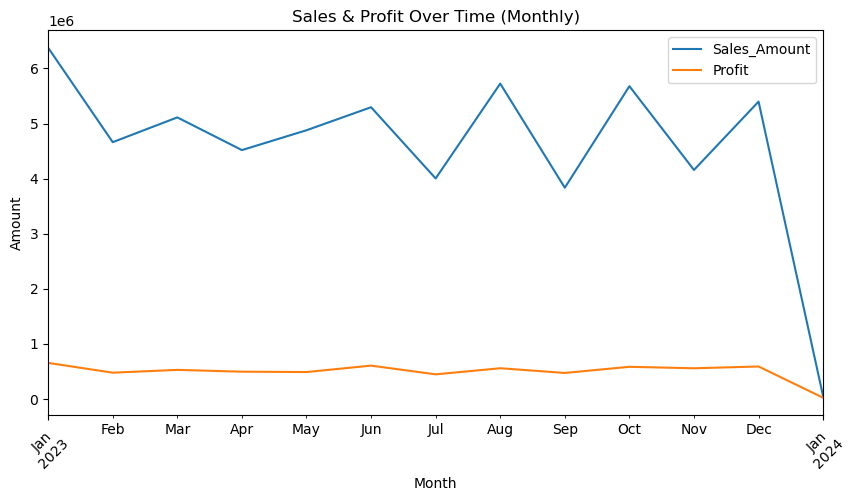

In [ ]:
import matplotlib.pyplot as plt

monthly_sales_profit.plot(figsize=(10,5))

plt.title('Sales & Profit Over Time (Monthly)')
plt.xlabel('Month')
plt.ylabel('Amount')
plt.xticks(rotation=45)
plt.show()

In [ ]:
top5_reps = df.groupby('Sales_Rep')['Sales_Amount'].sum().sort_values(ascending=False).head(5)
top5_reps

Sales_Rep
David     13,674,409.20
Eve       12,938,723.96
Bob       11,768,703.71
Alice     11,476,645.56
Charlie    9,827,690.85
Name: Sales_Amount, dtype: float64

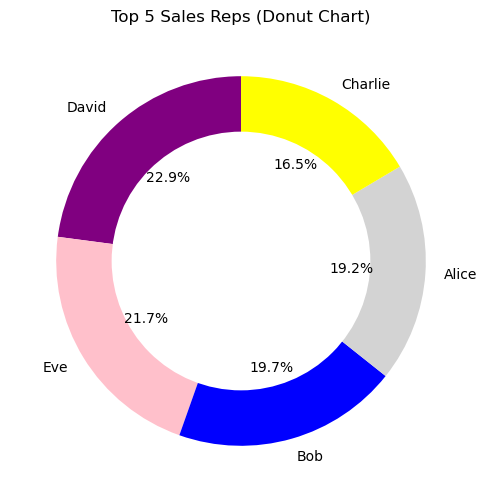

In [ ]:
import matplotlib.pyplot as plt

colors = ['purple', 'pink', 'blue', 'lightgray', 'yellow']

plt.figure(figsize=(6,6))
plt.pie(top5_reps, labels=top5_reps.index, autopct='%1.1f%%',
        startangle=90, colors=colors)

centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Top 5 Sales Reps (Donut Chart)')
plt.show()

In [ ]:
region_profit = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)
region_profit

Region
North   1,661,461.20
West    1,656,091.77
East    1,650,557.20
South   1,519,736.90
Name: Profit, dtype: float64

<Axes: ylabel='Region'>

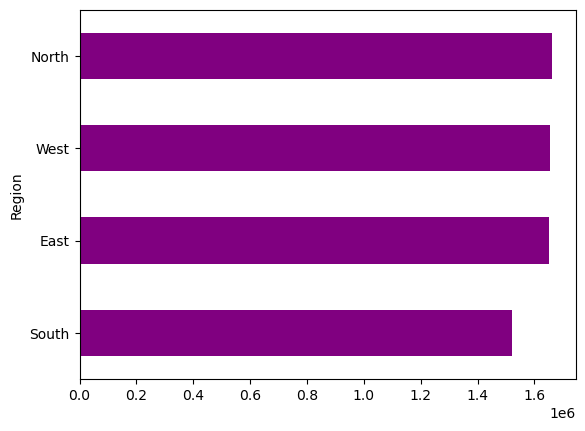

In [ ]:
region_profit = df.groupby('Region')['Profit'].sum().sort_values(ascending=True)

region_profit.plot(kind='barh', color='purple')

In [ ]:
best_product = df.groupby('Product_Category')['Profit'].sum().idxmax()
best_profit = df.groupby('Product_Category')['Profit'].sum().max()

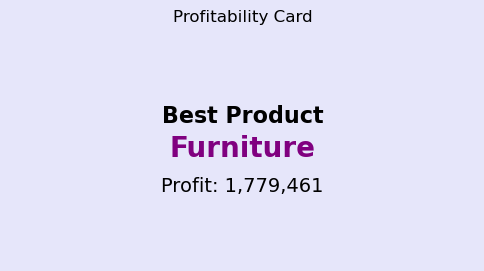

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,3), facecolor='lavender')

plt.text(0.5, 0.6, "Best Product", ha='center', fontsize=16, weight='bold', color='black')
plt.text(0.5, 0.45, best_product, ha='center', fontsize=20, weight='bold', color='purple')
plt.text(0.5, 0.3, f"Profit: {best_profit:,.0f}", ha='center', fontsize=14, color='black')

plt.axis('off')
plt.title('Profitability Card', fontsize=12)
plt.show()

In [ ]:
loyalty_counts = df['Customer_Type'].value_counts()
loyalty_percentage = df['Customer_Type'].value_counts(normalize=True) * 100

loyalty_percentage

Customer_Type
New         50.40
Returning   49.60
Name: proportion, dtype: float64

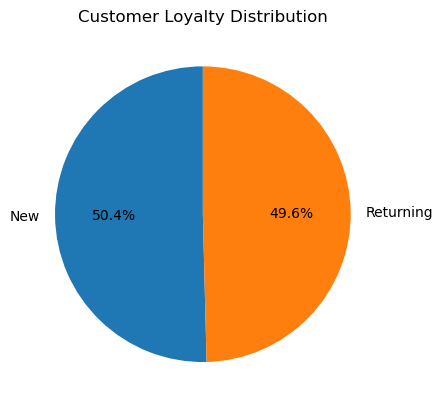

In [ ]:
import matplotlib.pyplot as plt

loyalty_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90)

plt.title('Customer Loyalty Distribution')
plt.ylabel('')
plt.show()

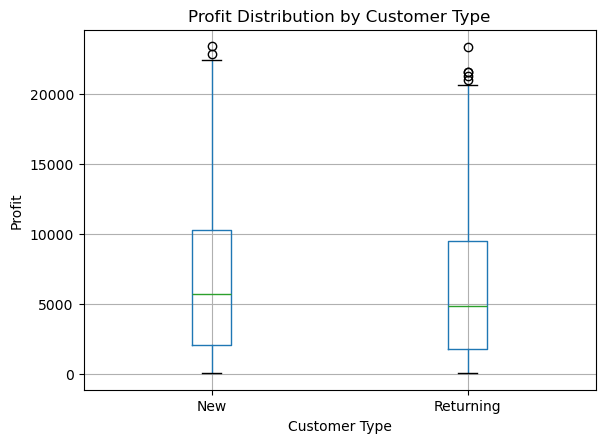

In [ ]:
import matplotlib.pyplot as plt

df.boxplot(column='Profit', by='Customer_Type')

plt.title('Profit Distribution by Customer Type')
plt.suptitle('')
plt.xlabel('Customer Type')
plt.ylabel('Profit')
plt.show()

In [ ]:
# Machine Learning & predicting Part 

In [ ]:
target = 'Sales_Amount' # تحديد العمود الذي سيتم التنبؤ به # الهدف الاساسي اللي تم بناء المودل علشان يعمله

In [ ]:
features = ['Quantity_Sold', 'Unit_Cost', 'Unit_Price', 'Discount', 'Profit']

In [ ]:
from sklearn.model_selection import train_test_split

# تحديد المدخلات (Features) والمخرجات (Target)
X = df[features]
y = df[target]

# تقسيم البيانات إلى تدريب واختبار
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [ ]:

from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)

In [ ]:
from xgboost import XGBRegressor

xgb = XGBRegressor(random_state=42)
xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error  #R² → جودة التفسير (كل ما قرب من 1 أفضل)
# RMSE → خطأ التنبؤ (كل ما قل أفضل)
import numpy as np

# حساب RMSE
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# تقييم Linear Regression
print("Linear Regression")
print("R2:", r2_score(y_test, model.predict(X_test)))
print("RMSE:", rmse(y_test, model.predict(X_test)))
print("-"*30)

# Decision Tree
print("Decision Tree")
print("R2:", r2_score(y_test, dt_pred))
print("RMSE:", rmse(y_test, dt_pred))
print("-"*30)

# Random Forest
print("Random Forest")
print("R2:", r2_score(y_test, rf_pred))
print("RMSE:", rmse(y_test, rf_pred))
print("-"*30)

# Gradient Boosting
print("Gradient Boosting")
print("R2:", r2_score(y_test, gb_pred))
print("RMSE:", rmse(y_test, gb_pred))
print("-"*30)

# XGBoost
print("XGBoost")
print("R2:", r2_score(y_test, xgb_pred))
print("RMSE:", rmse(y_test, xgb_pred))
print("-"*30)

Linear Regression
R2: 0.8742315028167806
RMSE: 17122.651712374896
------------------------------
Decision Tree
R2: 0.9756092702433017
RMSE: 7540.453815822768
------------------------------
Random Forest
R2: 0.9916713438886067
RMSE: 4406.2846788758
------------------------------
Gradient Boosting
R2: 0.9906123333565495
RMSE: 4678.039847617689
------------------------------
XGBoost
R2: 0.9879600110249694
RMSE: 5297.83138416022
------------------------------


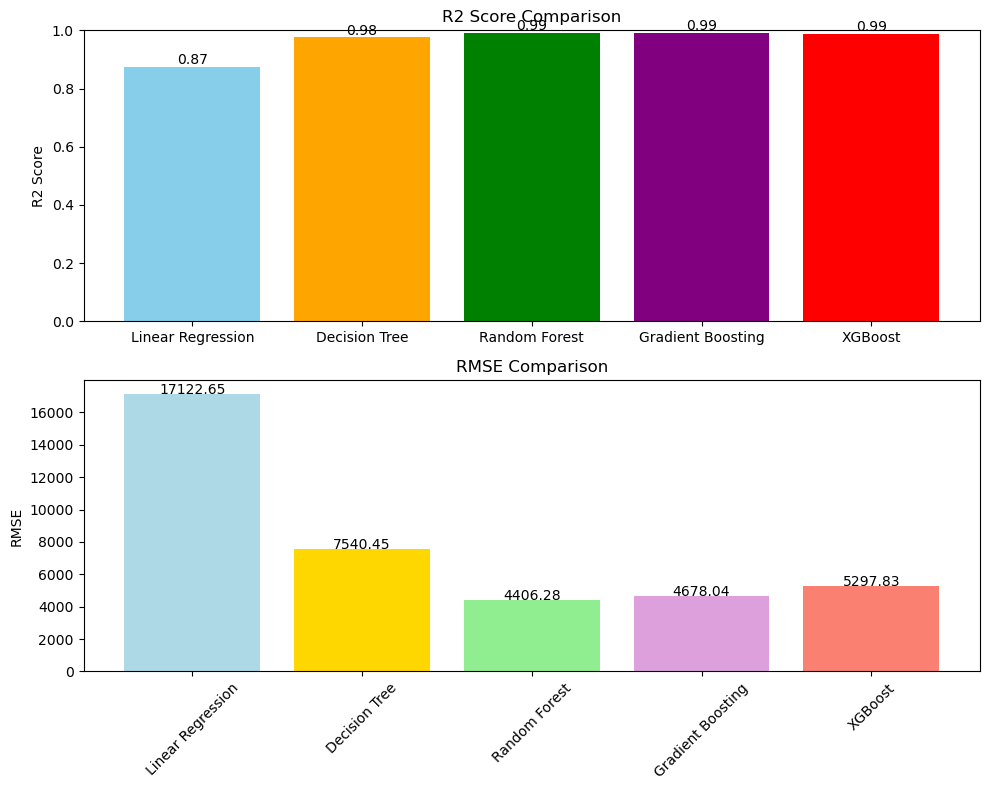

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = ['Linear Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting', 'XGBoost']

r2_scores = [
    r2_score(y_test, model.predict(X_test)),
    r2_score(y_test, dt_pred),
    r2_score(y_test, rf_pred),
    r2_score(y_test, gb_pred),
    r2_score(y_test, xgb_pred)
]

rmse_scores = [
    rmse(y_test, model.predict(X_test)),
    rmse(y_test, dt_pred),
    rmse(y_test, rf_pred),
    rmse(y_test, gb_pred),
    rmse(y_test, xgb_pred)
]

x = np.arange(len(models))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# ---------------- R2 ----------------
colors_r2 = ['skyblue', 'orange', 'green', 'purple', 'red']
ax1.bar(models, r2_scores, color=colors_r2)
ax1.set_title('R2 Score Comparison')
ax1.set_ylabel('R2 Score')
ax1.set_ylim(0, 1)

for i, v in enumerate(r2_scores):
    ax1.text(i, v + 0.01, f"{v:.2f}", ha='center')

# ---------------- RMSE ----------------
colors_rmse = ['lightblue', 'gold', 'lightgreen', 'plum', 'salmon']
ax2.bar(models, rmse_scores, color=colors_rmse)
ax2.set_title('RMSE Comparison')
ax2.set_ylabel('RMSE')

for i, v in enumerate(rmse_scores):
    ax2.text(i, v, f"{v:.2f}", ha='center')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()